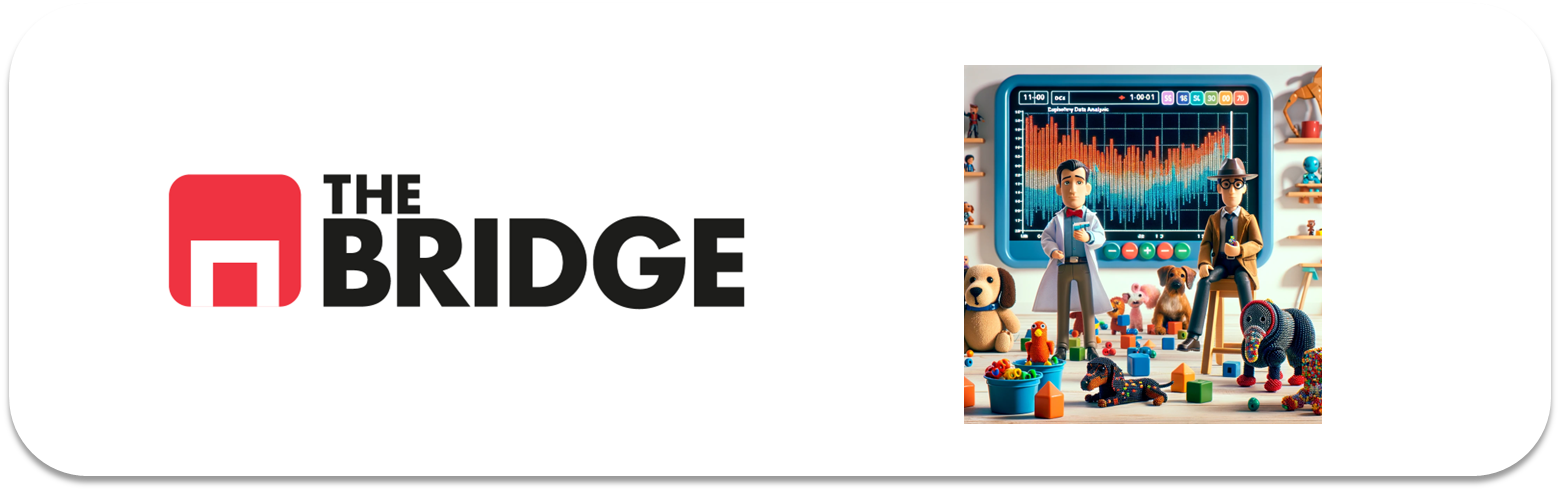

## PRACTICA OBLIGATORIA: ANÁLISIS MULTIVARIANTE

### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline


## #1 TITANIC

### #1.1

Carga en un dataframe el dataset del titanic, que está en la ruta "./data/titanic.csv".

In [5]:
import os
print(os.getcwd())

c:\Users\jvazq\Desktop\ONLINE_DS_THEBRIDGE-Trabajos-Jaime-V-zquez-\2-Analytics\7-Mates para DS\Ejercicios


In [8]:
import os
print(os.listdir("data"))

FileNotFoundError: [WinError 3] El sistema no puede encontrar la ruta especificada: 'data'

In [9]:
df = pd.read_csv("../data/titanic.csv")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### #1.2

Deshazte de las columnas "deck", "survived", "pclass" y "embarked" porque no las emplearemos, la primera por su cantidad de nulos y el resto porque son variantes de otras que ya existen y cuyos valores resultan más expresivos a la hora de hacer un análisis. 

In [10]:
df = df.drop(columns=["deck", "survived", "pclass", "embarked"])

### #1.3

Suma las columnas "parch" y "sibsp" para tener el número de parientes de cada pasajero, guarda el resultado en otra columna "family_members", luego deshazte de "parch" y "sibsp"

In [11]:
df["family_members"] = df["parch"] + df["sibsp"]
df = df.drop(columns=["parch", "sibsp"])

### #1.4

Imputa la moda a los valores nulos de "embark_town"

In [12]:
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

### #1.5

Imputa la media a los valores faltantes de "age", si quieres puedes hacer algo más preciso (por ejemplo considerando además la columna "who")

In [13]:
df["age"] = df["age"].fillna(df.groupby("who")["age"].transform("mean"))

### 1.6

Realiza los análisis bivariantes o multivariantes que necesites, así como los test de hipótesis necesarios para contestar a las siguientes preguntas. Nota: utiliza la variable "alive" para saber si un pasajero sobrevivió o no:

1. En términos absolutos, ¿sobrevivieron más hombres, mujeres o niños? ¿Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre el sexo y la supervivencia en el Titanic?¿Y entre ser adulto o ser niño?

2. En términos absolutos, ¿de que clase sobrevivieron más pasajeros?¿ Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre la clase en la que se viajaba y la supervivencia?

3. ¿De qué ciudad sobrevivieron más personas?¿Y porcentualmente de que ciudad sobrevivieron más personas? ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido?

4. ¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento?

5. Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? ¿Qué ocurrió con la persona que más dinero se dejó?

6. Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento. No necesitas aplicar ningún test, muestralo numérica o visualmente.

7. Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?

8. Finalmente, muestra las posibles relaciones entre edad, coste del billete y supervivencia/fallecimiento. ¿Qué puedes decir al respecto?

In [14]:
# Términos absolutos
df.groupby("who")["alive"].value_counts()

who    alive
child  yes       49
       no        34
man    no       449
       yes       88
woman  yes      205
       no        66
Name: count, dtype: int64

In [15]:
# Términos relativos
df.groupby("who")["alive"].value_counts(normalize=True)

who    alive
child  yes      0.590361
       no       0.409639
man    no       0.836127
       yes      0.163873
woman  yes      0.756458
       no       0.243542
Name: proportion, dtype: float64

In [16]:
# Test chi-cuadrado: ¿hay relación entre who y alive?
from scipy.stats import chi2_contingency

tabla = pd.crosstab(df["who"], df["alive"])
chi2, p, dof, expected = chi2_contingency(tabla)
print(f"p-valor: {p}")
print("Relación estadísticamente significativa" if p < 0.05 else "No hay relación significativa")

p-valor: 2.2227620817798914e-62
Relación estadísticamente significativa


In [17]:
# Términos absolutos y relativos
df.groupby("class")["alive"].value_counts()

class   alive
First   yes      136
        no        80
Second  no        97
        yes       87
Third   no       372
        yes      119
Name: count, dtype: int64

In [18]:
df.groupby("class")["alive"].value_counts(normalize=True)

class   alive
First   yes      0.629630
        no       0.370370
Second  no       0.527174
        yes      0.472826
Third   no       0.757637
        yes      0.242363
Name: proportion, dtype: float64

In [19]:
# Test chi-cuadrado
tabla = pd.crosstab(df["class"], df["alive"])
chi2, p, dof, expected = chi2_contingency(tabla)
print(f"p-valor: {p}")
print("Relación estadísticamente significativa" if p < 0.05 else "No hay relación significativa")

p-valor: 4.549251711298793e-23
Relación estadísticamente significativa


In [20]:
df.groupby("embark_town")["alive"].value_counts()

embark_town  alive
Cherbourg    yes       93
             no        75
Queenstown   no        47
             yes       30
Southampton  no       427
             yes      219
Name: count, dtype: int64

In [21]:
df.groupby("embark_town")["alive"].value_counts(normalize=True)

embark_town  alive
Cherbourg    yes      0.553571
             no       0.446429
Queenstown   no       0.610390
             yes      0.389610
Southampton  no       0.660991
             yes      0.339009
Name: proportion, dtype: float64

In [22]:
tabla = pd.crosstab(df["embark_town"], df["alive"])
chi2, p, dof, expected = chi2_contingency(tabla)
print(f"p-valor: {p}")
print("Relación estadísticamente significativa" if p < 0.05 else "No hay relación significativa")

p-valor: 2.3008626481449577e-06
Relación estadísticamente significativa


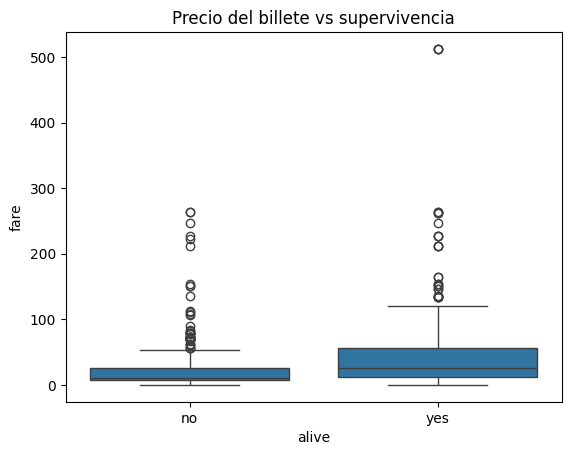

In [23]:
sns.boxplot(x="alive", y="fare", data=df)
plt.title("Precio del billete vs supervivencia")
plt.show()

In [24]:
# Test t de Student: ¿difieren las medias de fare entre vivos y muertos?
from scipy.stats import ttest_ind

vivos = df[df["alive"] == "yes"]["fare"]
muertos = df[df["alive"] == "no"]["fare"]
t, p = ttest_ind(vivos, muertos)
print(f"p-valor: {p}")
print("Diferencia significativa en el precio" if p < 0.05 else "No hay diferencia significativa")

p-valor: 6.1201893419242075e-15
Diferencia significativa en el precio


In [25]:
df[df["fare"] == 0]

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members
179,male,36.000000,0.0,Third,man,True,Southampton,no,True,0
263,male,40.000000,0.0,First,man,True,Southampton,no,True,0
271,male,25.000000,0.0,Third,man,True,Southampton,yes,True,0
277,male,33.173123,0.0,Second,man,True,Southampton,no,True,0
302,male,19.000000,0.0,Third,man,True,Southampton,no,True,0
413,male,33.173123,0.0,Second,man,True,Southampton,no,True,0
466,male,33.173123,0.0,Second,man,True,Southampton,no,True,0
481,male,33.173123,0.0,Second,man,True,Southampton,no,True,0
597,male,49.000000,0.0,Third,man,True,Southampton,no,True,0
633,male,33.173123,0.0,First,man,True,Southampton,no,True,0


In [26]:
# El que más pagó
df.loc[df["fare"].idxmax()]

sex                  female
age                    35.0
fare               512.3292
class                 First
who                   woman
adult_male            False
embark_town       Cherbourg
alive                   yes
alone                  True
family_members            0
Name: 258, dtype: object

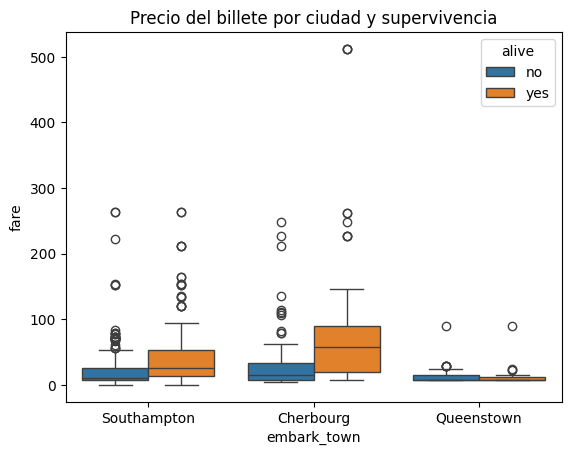

In [27]:
sns.boxplot(x="embark_town", y="fare", hue="alive", data=df)
plt.title("Precio del billete por ciudad y supervivencia")
plt.show()

In [28]:
# Términos absolutos
df.groupby(["class", "who"])["alive"].value_counts()

class   who    alive
First   child  yes        5
               no         1
        man    no        77
               yes       42
        woman  yes       89
               no         2
Second  child  yes       19
        man    no        91
               yes        8
        woman  yes       60
               no         6
Third   child  no        33
               yes       25
        man    no       281
               yes       38
        woman  no        58
               yes       56
Name: count, dtype: int64

In [29]:
# Términos relativos
df.groupby(["class", "who"])["alive"].value_counts(normalize=True)

class   who    alive
First   child  yes      0.833333
               no       0.166667
        man    no       0.647059
               yes      0.352941
        woman  yes      0.978022
               no       0.021978
Second  child  yes      1.000000
        man    no       0.919192
               yes      0.080808
        woman  yes      0.909091
               no       0.090909
Third   child  no       0.568966
               yes      0.431034
        man    no       0.880878
               yes      0.119122
        woman  no       0.508772
               yes      0.491228
Name: proportion, dtype: float64

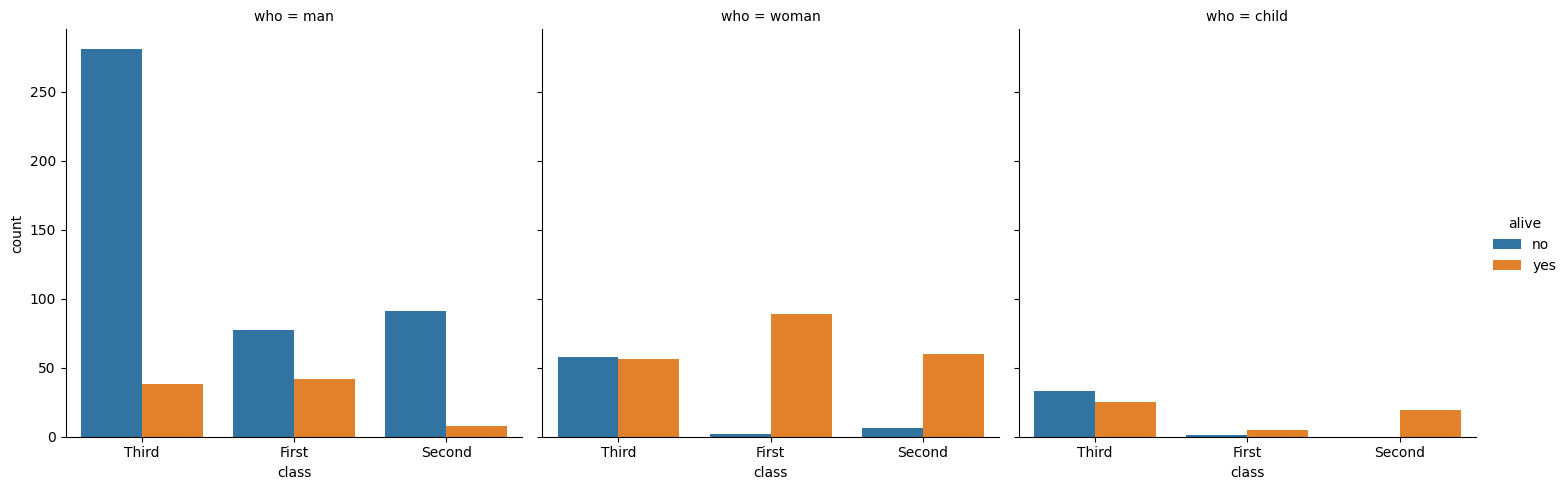

In [30]:
sns.catplot(x="class", hue="alive", col="who", data=df, kind="count")
plt.show()

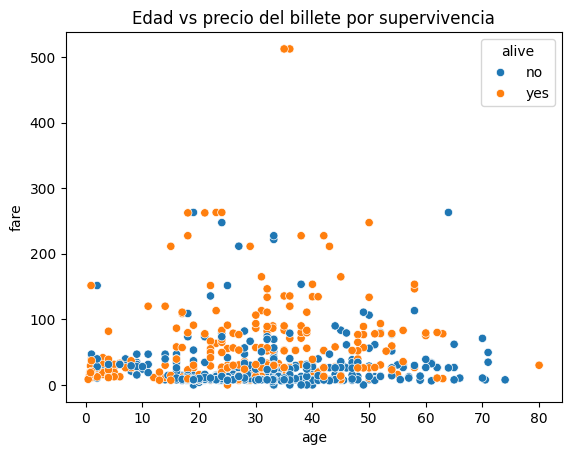

In [31]:
sns.scatterplot(x="age", y="fare", hue="alive", data=df)
plt.title("Edad vs precio del billete por supervivencia")
plt.show()

## #2 Viajes

El objetivo en este caso no es tanto hacer un montón de análisis sino entender cómo de un dataset podemos obtener preguntas o hipótesis interesantes (si las hay)

### #2.1 

Carga el dataset de viajes del mes de junio. Repite el análisis bivariante entre las variables "Aircompany" e "Ingresos", mostrando previamente los viajes por compañía aérea. ¿Qué situación llamativa nos surgió? (Ten en cuenta que somos el departamenteo de DataScience de TabarAir)

In [32]:
df_viajes = pd.read_csv("../data/dataset_viajes_jun23.csv")
df_viajes.head()

,aircompany,origen,destino,distancia,avion,con_escala,consumo_kg,duracion,ingresos,id_vuelo,mes
0,Airnar,París,Ginebra,411,Boeing 737,False,1028.691900,51,14232.65,Air_PaGi_10737,Jun23
1,FlyQ,Bali,Roma,12738,Boeing 737,True,33479.132544,1167,468527.19,Fly_BaRo_10737,Jun23
2,TabarAir,Ginebra,Los Angeles,9103,Airbus A380,False,109439.907200,626,584789.19,Tab_GiLo_11380,Jun23
3,MoldaviAir,París,Cincinnati,6370,Boeing 737,False,17027.010000,503,233342.51,Mol_PaCi_10737,Jun23
4,TabarAir,Cincinnati,Roma,7480,Boeing 747,False,86115.744000,518,438535.07,Tab_CiRo_10747,Jun23


In [34]:
print(df_viajes.columns.tolist())

['aircompany', 'origen', 'destino', 'distancia', 'avion', 'con_escala', 'consumo_kg', 'duracion', 'ingresos', 'id_vuelo', 'mes']


In [35]:
# Viajes por compañía aérea
df_viajes["aircompany"].value_counts()

aircompany
TabarAir      142
MoldaviAir    133
PamPangea     117
FlyQ          108
Airnar        100
Name: count, dtype: int64

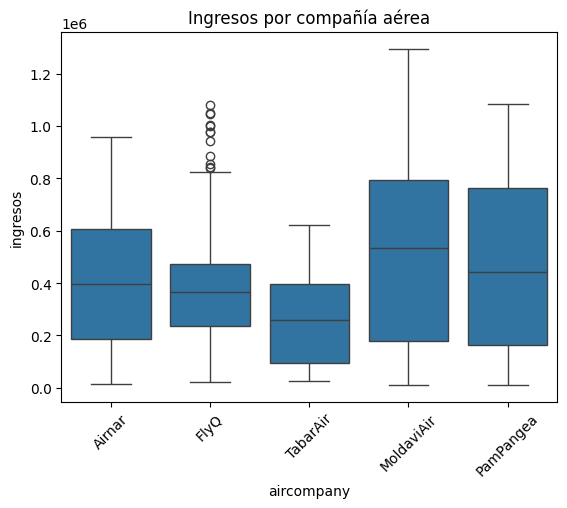

In [36]:
sns.boxplot(x="aircompany", y="ingresos", data=df_viajes)
plt.title("Ingresos por compañía aérea")
plt.xticks(rotation=45)
plt.show()

In [37]:
df_viajes.groupby("aircompany")["ingresos"].mean().sort_values()

aircompany
TabarAir      271042.230282
FlyQ          401619.008056
Airnar        405293.978200
PamPangea     478417.048718
MoldaviAir    548077.209098
Name: ingresos, dtype: float64

### #2.2

Repite el análisis multivariante entre "ingresos","distancias" y "consumo_kg". ¿Qué veíamos que parecía también muy prometedor?

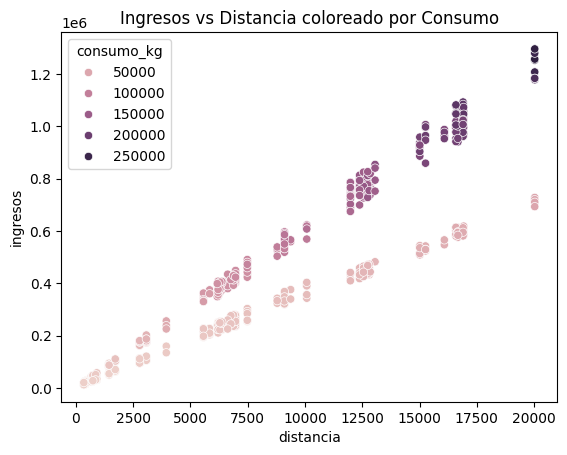

In [38]:
sns.scatterplot(x="distancia", y="ingresos", hue="consumo_kg", data=df_viajes)
plt.title("Ingresos vs Distancia coloreado por Consumo")
plt.show()

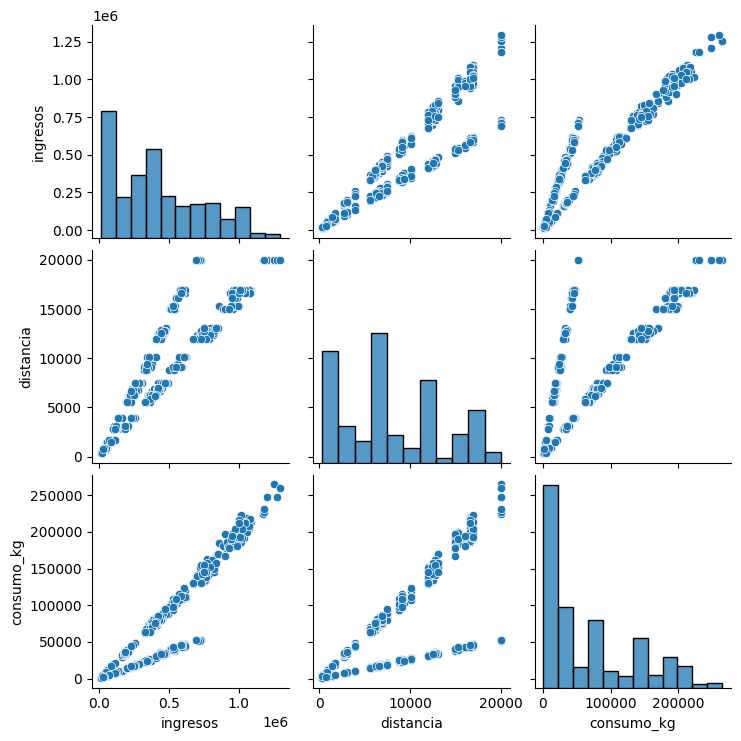

In [39]:
sns.pairplot(df_viajes[["ingresos", "distancia", "consumo_kg"]])
plt.show()

In [40]:
# Correlaciones entre las tres variables
df_viajes[["ingresos", "distancia", "consumo_kg"]].corr()

,ingresos,distancia,consumo_kg
ingresos,1.000000,0.928833,0.944875
distancia,0.928833,1.000000,0.762341
consumo_kg,0.944875,0.762341,1.000000


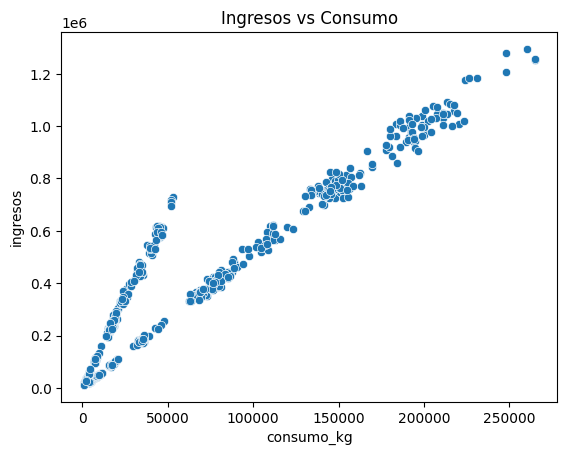

In [41]:
# Lo llamativo: hay una línea de vuelos con mucho consumo y pocos ingresos (poco eficientes)
# y otra línea con menos consumo y más ingresos (muy eficientes)
sns.scatterplot(x="consumo_kg", y="ingresos", data=df_viajes)
plt.title("Ingresos vs Consumo")
plt.show()

### #2.3

Crea una variable categorica "cat_vuelo" a partir de distancias, escoge los rangos de las categorías basándote en la distribución de valores de "distancia" (sugerencia entre 3 y 4 categorías). Extra: Realiza ahora otra vez el análisis multivariante "cat_vuelo", "ingresos", "consumo_kg". ¿Ves algo diferente?

In [ ]:

df_viajes["distancia"].describe()

count      600.000000
mean      8071.003333
std       5550.244086
min        344.000000
25%       3073.000000
50%       6877.000000
75%      12553.000000
max      20029.000000
Name: distancia, dtype: float64

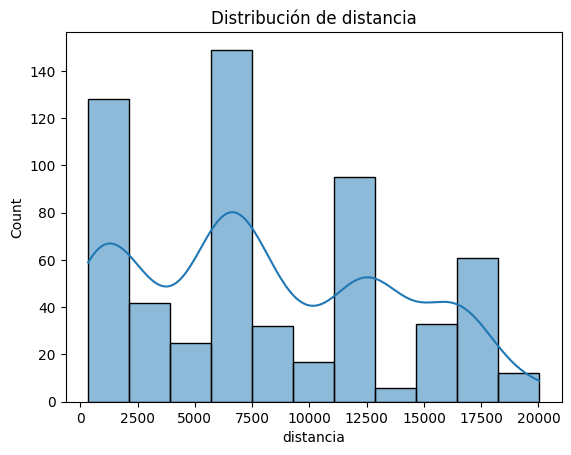

In [43]:
sns.histplot(df_viajes["distancia"], kde=True)
plt.title("Distribución de distancia")
plt.show()

In [ ]:

df_viajes["cat_vuelo"] = pd.cut(df_viajes["distancia"], 
                                 bins=[0, 1000, 3000, df_viajes["distancia"].max()],
                                 labels=["corto", "medio", "largo"])
df_viajes["cat_vuelo"].value_counts()

cat_vuelo
largo    454
corto     94
medio     52
Name: count, dtype: int64

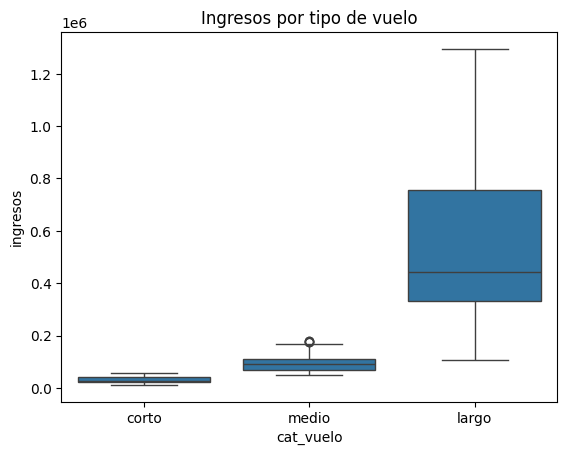

In [45]:
# Análisis multivariante cat_vuelo, ingresos, consumo_kg
sns.boxplot(x="cat_vuelo", y="ingresos", data=df_viajes)
plt.title("Ingresos por tipo de vuelo")
plt.show()

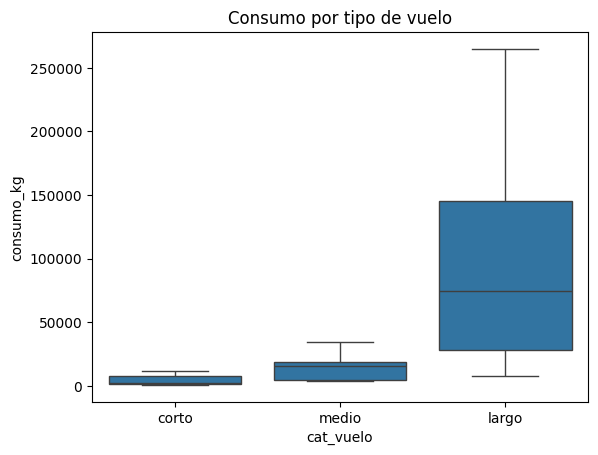

In [46]:
sns.boxplot(x="cat_vuelo", y="consumo_kg", data=df_viajes)
plt.title("Consumo por tipo de vuelo")
plt.show()

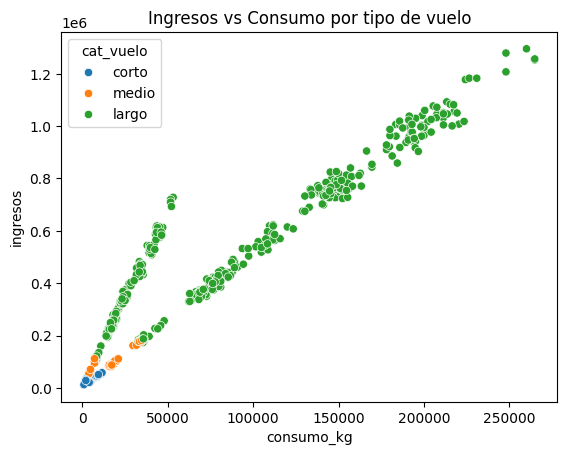

In [ ]:
sns.scatterplot(x="consumo_kg", y="ingresos", hue="cat_vuelo", data=df_viajes)
plt.title("Ingresos vs Consumo por tipo de vuelo")
plt.show()

### Extra:

#1 Consejos para encontrar "objetivos":

Si partes de un dataset que te parece interesante pero sin pregruntras claras, haz como hicimos con el dataset de Aviones. Describe, prioriza a ojo tus variables, realiza un análisis univariante completo, realiza un análisis bivariante ente las parejas de variables que te parecieron más intereantes. Llegados a este punto si el dataset tiene riqueza informativa, algo diferente tiene que haber aparecido (otra cosa es que sea interesante para ti :-)).  

Fíjate en lo que encontramos en el dataset de viajes: la empresa de más vuelos es la que menos ingresos tiene o la existencia clara de una línea de vuelos más eficientes en consumo que otros y otra de mayor ingresos por consumo. Lo siguiente es explorar esos puntos normalmente intentando contestar a: ¿por qué pasa?¿dónde,cuándo o cómo pasa?  

Busca esas "notas discordantes" en tu dataset, ya de por sí son mensajes del análisis. Ordénalas por importancia (importancia = impactan en ingresos, impactan en la calidad de la vida de las personas, impactan en el coste y poco más hay) e intenta entender por qué suceden esas notas discordantes, cómo solucionarlas o aprovecharlas y ya tienes objeetivos para el EDA; incluso si no encuentras respuesta siempre tendras esas notas discordantes, la conclusión de que no se puede avanzar con los datos que se tienen y los próximos pasos de encontrar más información para explicar lo que ocurre.

#2 Contestando a las preguntas de "Viajes".

- Necesitamos identificar esas líneas eficientes, para ello crea una variable que mida el ingreso por kilogramo consumido y otra que mida el kilogramo consumido por kilómetro. Haz el análisis univariante de las mismas intentando encontrar una diferencia clara entre viajes eficientes y no eficientes (que sabemos que existe). Fija un umbral para indicar si un viaje es supereficiente o si no lo es
- Crea esa variable de eficiencia binaria de eficiencia.
- Ahora haz el análisis bivariante de esa eficiencia y las compañías aéreas (queremos ver si realmente eso explica la situación de TabarAir). 
- Para nota: Hacer los análisis multivariante por compañía, eficiencia, tipo de avión y compañía, eficiencia, destino e incluso el de compañía, eficiencia, origen, destino.
- Con todo ello deberías poder encontrar si hay respuesta a la situación de TabarAir además de poder mostrar otros datos interesantes.

In [48]:
# Ingreso por kilogramo consumido
df_viajes["ingreso_por_kg"] = df_viajes["ingresos"] / df_viajes["consumo_kg"]

# Kilogramo consumido por kilómetro
df_viajes["kg_por_km"] = df_viajes["consumo_kg"] / df_viajes["distancia"]

df_viajes[["ingreso_por_kg", "kg_por_km"]].describe()

,ingreso_por_kg,kg_por_km
count,600.000000,600.000000
mean,8.904848,7.934756
std,4.407691,4.537013
min,4.554666,2.430000
25%,5.131672,2.660600
50%,5.459427,11.086400
75%,13.855693,11.906800
max,16.213469,13.224640


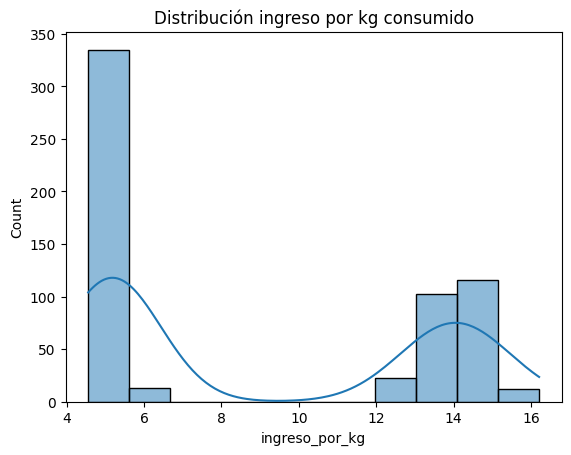

In [49]:
sns.histplot(df_viajes["ingreso_por_kg"], kde=True)
plt.title("Distribución ingreso por kg consumido")
plt.show()

In [50]:
# Fijamos umbral de eficiencia — vuelos supereficientes: alto ingreso/kg y bajo kg/km
umbral_ingreso = df_viajes["ingreso_por_kg"].median()
umbral_consumo = df_viajes["kg_por_km"].median()

df_viajes["supereficiente"] = (df_viajes["ingreso_por_kg"] > umbral_ingreso) & (df_viajes["kg_por_km"] < umbral_consumo)
df_viajes["supereficiente"].value_counts()

supereficiente
False    324
True     276
Name: count, dtype: int64

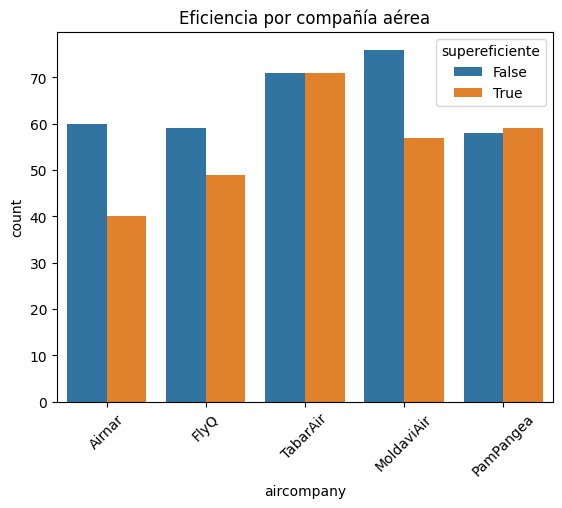

In [51]:
# Análisis bivariante eficiencia y compañía aérea
sns.countplot(x="aircompany", hue="supereficiente", data=df_viajes)
plt.title("Eficiencia por compañía aérea")
plt.xticks(rotation=45)
plt.show()

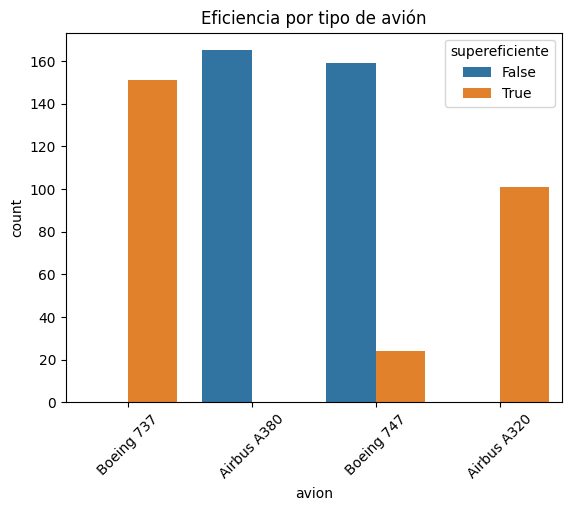

In [52]:
# Para nota: eficiencia por tipo de avión
sns.countplot(x="avion", hue="supereficiente", data=df_viajes)
plt.title("Eficiencia por tipo de avión")
plt.xticks(rotation=45)
plt.show()

In [53]:
# Para nota: eficiencia por compañía y destino
df_viajes.groupby(["aircompany", "destino"])["supereficiente"].mean().sort_values(ascending=False).head(10)

aircompany  destino    
FlyQ        Ginebra        0.722222
            Cincinnati     0.642857
TabarAir    Los Angeles    0.590909
PamPangea   París          0.576923
            Nueva York     0.571429
            Ginebra        0.541667
TabarAir    Roma           0.535714
            Nueva York     0.520000
Airnar      Cincinnati     0.500000
TabarAir    Londres        0.478261
Name: supereficiente, dtype: float64